In [8]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

def black_scholes_price_greeks(call:bool, S0:float, K:float, vol:float, T:float, r:float):

    if S0 <= 0 or K <= 0 or vol <= 0 or T <= 0:
        raise ValueError("S0, K, vol, and T must all be positive.")

    d1 = (np.log(S0 / K) + (r + vol**2 / 2) * T) / (vol * np.sqrt(T))
    d2 = d1 - (vol * np.sqrt(T))

    if call:
        price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)

    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1

    gamma = norm.pdf(d1) / (S0 * vol * np.sqrt(T))
    vega = 0.01 * S0 * norm.pdf(d1) * np.sqrt(T)
    
    return {"price": price,
            "delta": delta,
            "gamma": gamma,
            "vega": vega}

In [54]:
def solve_IV_bisection(call, option_price, S0, K, T, r, tol=1e-3, max_iters=1000):
    vol_low, vol_high = 0, 1
    vol_estimates = []

    for i in range(max_iters):
        vol_est = (vol_low + vol_high) / 2
        vol_estimates.append(vol_est)
        price_est = black_scholes_price_greeks(call, S0, K, vol_est, T, r)["price"]

        if abs(price_est - option_price) < tol:
            return i, vol_estimates
        elif price_est > option_price:
            vol_high = vol_est
        else:
            vol_low = vol_est

    print("failed")
    return -1

Iterations to convergence: 13
Vol estimate: 0.20001220703125


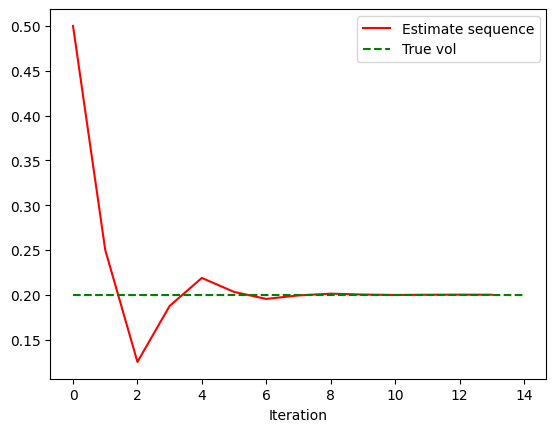

In [58]:
call=True
S0=100
K=100
true_vol=0.2
T=1
r=0.05

market_price = black_scholes_price_greeks(call, S0, K, true_vol, T, r)["price"]

iterations, vol_estimates = solve_IV_bisection(call, market_price, S0, K, T, r)

print(f"Iterations to convergence: {iterations}")
print(f"Vol estimate: {vol_estimates[~0]}")

plt.figure()
plt.plot(vol_estimates, color="r")
plt.hlines(true_vol, xmin=0, xmax=len(vol_estimates), color="g", linestyle="dashed")
plt.xlabel("Iteration")
plt.legend(["Estimate sequence", "True vol"])
plt.show()